# **Multi-omics Cohort Building with Cancer Data Aggregator**

# Example use case:

This notebook aims to demonstrate building a cohort of specific data types using the Cancer Data Aggregator (CDA). We will be retrieving mutation and gene expression data stored at the Genomic Data Commons (GDC), protein intensity data stored at the Proteomic Data Commons (PDC), and in the future tumor characteristics derived from slide images stored at the Imaging Data Commons (IDC). We then demonstrate how to retrieve the desired derived data of these cases from the ISB-CGC ecosystem to immediatly feed into statistical analyses.

For more information about the CDA data and API visit their site:
https://cda.readthedocs.io

For more information about the ISB-CGC and the BigQuery Data Ecosystem visit our site:
https://isb-cgc.org

---


# Setup steps:
First we import the CDA python packages and functions we will be using.

In [1]:
try:
  from itables import(
     init_notebook_mode, show
    )
except:
  !pip install -r https://raw.githubusercontent.com/CancerDataAggregator/Community-Notebooks/main/requirements.txt


import numpy as np
import pandas as pd
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)
import itables.options as opt

opt.classes="display"
opt.buttons=["copyHtml5", "csvHtml5", "excelHtml5"]
opt.maxBytes=0

  Cloning https://github.com/CancerDataAggregator/cdapython.git (to revision develop) to /tmp/pip-req-build-fgugw9u0
  Running command git clone --filter=blob:none --quiet https://github.com/CancerDataAggregator/cdapython.git /tmp/pip-req-build-fgugw9u0
  Resolved https://github.com/CancerDataAggregator/cdapython.git to commit ce99afc87e98003deaeb38a368e0cc76f32ec1e8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.9/268.9 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.8/398.8 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [2]:
from cdapython import * #tables, columns, column_values, fetch_rows, summary_counts

---

The `tables()` function from the CDA package simply returns a list of tables tables available. These tables each contain various information about the patients in the three Data Commons.

In [3]:
tables()

['file',
 'mutation',
 'observation',
 'project',
 'subject',
 'treatment',
 'upstream_identifiers']

Considering we are interested in specific data types we can further query the columns of the `file` table by use of the `columns()` function. This returns a set of columns, the format of the data contained in these columns, and a short description.

In [4]:
columns(table=['file'])

Loading ITables v2.7.3 from the internet... (need help?)


From browsing the results we can infer that `file_type` is likely to contain the information we are after. We can further interrogate the CDA data and retrieve a list of possible values in each field via the `column_values()` which we apply to the `file_type` column.

In [5]:
column_values('file_type')

Loading ITables v2.7.3 from the internet... (need help?)


---

The function returns a list of possible data types associated with all subjects. We can browse this and select those pertinent to our analysis. Specifically we will be relying on the `file_type` and `data_source` fields. For example, we can retrieve all cases with Pathology Reports as below:

In [6]:
pathology = get_file_data(match_all=['file_type = Pathology Report'])
pathology.head(3)

Loading ITables v2.7.3 from the internet... (need help?)


# Selecting data types

To simplify the cohort building process we will query for data from each data commons (genomic, proteomic, imaging) separately and then perform set operations to determine the overlap. For the genomic component of our analysis we will first retrieve a list of cases with mutation data available from the GDC, followed by the set of cases with RNA gene expression data. More information about the data processing pipelines used by the GDC can be found in their documentation.

https://gdc.cancer.gov/about-data/gdc-data-processing/genomic-data-processing

Our first query to retrieve those cases from the GDC that have **Somatic Mutation** data:

In [7]:
gdc_mutation = get_subject_data(match_any = ["file_type = Aggregated Somatic Mutation", "file_type = Annotated Somatic Mutation"],
                                data_source = ['GDC'])
gdc_mutation.head(3)

Loading ITables v2.7.3 from the internet... (need help?)


We can then further query for those cases within the GDC with **Gene Expression** data:

In [8]:
gdc_expression = get_subject_data(match_all = ["file_type = Gene Expression Quantification"],
                                  data_source = ['GDC'])
gdc_expression.head(3)

Loading ITables v2.7.3 from the internet... (need help?)


Swapping data commons we can look for those cases that have some **Masked Intensities**, a measure of protein abundance, from the PDC. For more information about the PDC data processing pipelines for these data check the PDC documentation below.

https://proteomic.datacommons.cancer.gov/pdc/harmonization

In [9]:
pdc_intensity = get_subject_data(match_all=["file_type = Masked Intensities"],
                           data_source = ['PDC'])
pdc_intensity.head(3)

Loading ITables v2.7.3 from the internet... (need help?)


Finally for completeness we query for those cases that have **Slide Images** within the IDC. As with the other commons, more information about the data stored in the IDC and specifically the DICOM format can be found in their documentation.

https://learn.canceridc.dev/

In [10]:
idc_slide = get_subject_data(match_all=["file_type = Slide Image"],
                       data_source = ['IDC'])
idc_slide.head(3)

Loading ITables v2.7.3 from the internet... (need help?)


# Analyses

We've generated the lists of cases with the relevant data types available. With these data tables we can generate the overlap to determine our final cohort size through set operations and can retrieve the derived data directly from ISB-CGC hosted BiqQuery tables. BigQuery is a tool with unique scaling functionality allowing us to quickly perform table joins between these data tables. For more information about the ISB-CGC BigQuery ecosystem we have a short introductory video.

https://www.youtube.com/watch?v=5hVgGW346wI

We can visualize the overlap between our case lists with a venn diagram, for this we'll install the `venny4py` python package as well as a few bigquery functions and `pandas`.

In [11]:
!pip install venny4py
from venny4py.venny4py import *
from google.cloud import bigquery
from google.colab import auth
import pandas as pd

<Figure size 1200x1200 with 0 Axes>

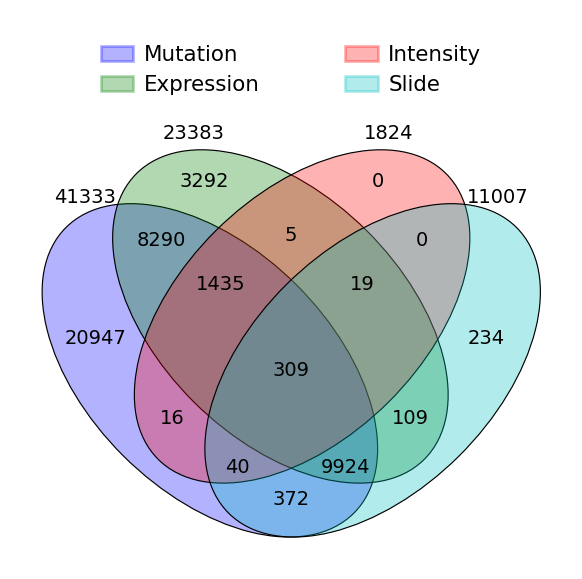

In [12]:
sets = {
    'Mutation': set(gdc_mutation['subject_id']) - set([None]),
    'Expression': set(gdc_expression['subject_id']) - set([None]),
    'Intensity': set(pdc_intensity['subject_id']) - set([None]),
    'Slide': set(idc_slide['subject_id']) - set([None])
}

plt.figure(figsize=(4,4), dpi=300)
venny4py(sets=sets)

In [13]:
final_set = sets['Mutation'].intersection(sets['Expression']).intersection(sets['Intensity']).intersection(sets['Slide'])
formatted_identifiers = ','.join(['"{}"'.format(x.split('.')[1]) for x in final_set])
print(','.join(final_set))

TCGA.TCGA-AN-A0AS,TCGA.TCGA-24-1416,TCGA.TCGA-30-1891,TCGA.TCGA-C8-A12L,TCGA.TCGA-BH-A0AV,TCGA.TCGA-24-1563,TCGA.TCGA-13-1511,TCGA.TCGA-61-1995,TCGA.TCGA-AA-3986,TCGA.TCGA-C8-A131,TCGA.TCGA-09-2056,TCGA.TCGA-24-1474,TCGA.TCGA-29-1698,TCGA.TCGA-AG-A01W,TCGA.TCGA-AO-A12B,TCGA.TCGA-25-2399,TCGA.TCGA-A2-A0D0,TCGA.TCGA-29-1688,TCGA.TCGA-AA-3695,TCGA.TCGA-AA-A022,TCGA.TCGA-24-2298,TCGA.TCGA-AR-A1AS,TCGA.TCGA-A6-3808,TCGA.TCGA-61-1919,TCGA.TCGA-AG-A026,TCGA.TCGA-A6-3810,TCGA.TCGA-24-1467,TCGA.TCGA-AA-3989,TCGA.TCGA-AA-3529,TCGA.TCGA-A2-A0T1,TCGA.TCGA-AA-3715,TCGA.TCGA-AF-3400,TCGA.TCGA-25-1623,TCGA.TCGA-61-1907,TCGA.TCGA-61-1741,TCGA.TCGA-A7-A0CD,TCGA.TCGA-BH-A0DG,TCGA.TCGA-AA-A01Z,TCGA.TCGA-C8-A138,TCGA.TCGA-BH-A0C7,TCGA.TCGA-C8-A12U,TCGA.TCGA-AA-A02Y,TCGA.TCGA-AN-A04A,TCGA.TCGA-AA-A02E,TCGA.TCGA-13-1507,TCGA.TCGA-AA-A01X,TCGA.TCGA-13-1410,TCGA.TCGA-29-2427,TCGA.TCGA-AA-A02R,TCGA.TCGA-AO-A12F,TCGA.TCGA-AR-A0TR,TCGA.TCGA-E2-A150,TCGA.TCGA-A2-A0T6,TCGA.TCGA-AN-A0FL,TCGA.TCGA-25-1631,TCGA.TCGA-

Our final overlap of cases across the four chosen data type is 265 cases, all from the TCGA project. This helpfully simplifies the process of retrieving data from the BigQuery ecosystem. To view a searchable interface of these tables we can visit the BigQuery Search Tool:

https://isb-cgc.appspot.com/bq_meta_search/

After review the data we are interested in is stored in the following tables for our genomic data types:

*  isb-cgc-bq.TCGA_versioned.RNAseq_hg38_gdc_r35
*  isb-cgc-bq.TCGA.masked_somatic_mutation_hg38_gdc_current

And for our proteomic data type:

* isb-cgc-bq.TCGA.quant_proteome_TCGA_breast_cancer_pdc_current
* isb-cgc-bq.TCGA.quant_proteome_TCGA_ovarian_JHU_pdc_current
* isb-cgc-bq.TCGA.quant_proteome_TCGA_ovarian_PNNL_pdc_current

To retrieve data from BigQuery we have to authenticate and provide a project to charge. The cost of executing the queries in this notebook total to a few cents.



In [16]:
google_project = "broad-cda-dev"
client = bigquery.Client(project=google_project) # replace this project with your own
auth.authenticate_user()

# BQ SQL queries


SQL queries are fundamentally very similar to Excel macros or subsetting R data frames, where the syntax of subsetting an R data frame is as follows:

    dataframe[ ,column ][ conditional ]

The equivalent operation in SQL would look like this:

    SELECT column FROM table WHERE conditional

For our first query we will retrieve the RNA sequencing fpkm values, the gene names, the project name specifically for tumor samples. We will use the identifiers retrieved from CDA to subset for only those cases in our simple cohort. For the purposes of this instructional notebook we are focusing exclusively on the gene ERBB2.

In [17]:
expression_query = f"""
  select
    case_barcode,
    project_short_name,
    gene_name,
    fpkm_uq_unstranded,
    sample_type_name
  from `isb-cgc-bq.TCGA_versioned.RNAseq_hg38_gdc_r35`
  where case_barcode in ({formatted_identifiers})
  and gene_name = 'ERBB2'
  and sample_type_name = 'Primary Tumor'
"""
query_job = client.query(expression_query)
expr_df = query_job.result().to_dataframe()
expr_df.head(3)
#len(expr_df)

Loading ITables v2.7.3 from the internet... (need help?)


Next we are querying the mutation table, somatic mutations in these tables are all called from tumor samples and in the gene ERBB2.

In [18]:
mutation_query = f"""
  select
    case_barcode,
    project_short_name,
    SYMBOL,
    Variant_Classification
  from `isb-cgc-bq.TCGA_versioned.masked_somatic_mutation_hg38_gdc_r36`
  where case_barcode in ({formatted_identifiers})
  and SYMBOL = 'ERBB2'
"""
query_job = client.query(mutation_query)
mutation_df = query_job.result().to_dataframe()
mutation_df.head(3)
#len(mutation_df)

Loading ITables v2.7.3 from the internet... (need help?)


The final query before we join between our three data types are on PDC quantitative proteome tables. These data are split into separate tables by "project" so we use the union function to concate them. We also join to the case and aliquot mapping tables to retrieve `sample_type` so we can subset for Tumor samples only.

In [19]:
abundance_query = f"""
  select
    meta.case_submitter_id,
    gene_symbol,
    quant.protein_abundance_log2ratio,
    aliquot.sample_type
  from (select *
    from `isb-cgc-bq.TCGA_versioned.quant_proteome_TCGA_breast_cancer_pdc_V2_10`
    union all select * from `isb-cgc-bq.TCGA_versioned.quant_proteome_TCGA_ovarian_JHU_pdc_V2_10`
    union all select * from `isb-cgc-bq.TCGA_versioned.quant_proteome_TCGA_ovarian_PNNL_pdc_V2_10`) quant
  join `isb-cgc-bq.PDC_metadata_versioned.case_metadata_V2_10` meta
  on quant.case_id = meta.case_id
  join `isb-cgc-bq.PDC_metadata_versioned.aliquot_to_case_mapping_V2_10` aliquot
  on quant.aliquot_id = aliquot.aliquot_id
  where meta.case_submitter_id in ({formatted_identifiers})
  and gene_symbol = 'ERBB2'
"""
query_job = client.query(abundance_query)
abundance_df = query_job.result().to_dataframe()
abundance_df.head(3)
#len(abundance_df)

Loading ITables v2.7.3 from the internet... (need help?)


Finally we can use BigQuery to join between the three other queries we generated for a table containing the project, gene name, fpkm, protein abundance, and variant classification. This returns a table of 214 cases close to our expected 265.

In [20]:
combined_query = f"""
  select
    expression.case_barcode,
    expression.project_short_name,
    expression.gene_name,
    fpkm_uq_unstranded,
    protein_abundance_log2ratio,
    Variant_Classification
  from ({expression_query}) expression
  join ({abundance_query}) abundance
    on expression.case_barcode = abundance.case_submitter_id
  full outer join ({mutation_query}) mutation
    on expression.case_barcode = mutation.case_barcode
    and expression.project_short_name = mutation.project_short_name
  where fpkm_uq_unstranded is not null
"""
#print(combined_query)
query_job = client.query(combined_query)
combined_df = query_job.result().to_dataframe()
combined_df
#len(combined_df)

Loading ITables v2.7.3 from the internet... (need help?)


# Graphics

With this joined data frame in hand we can begin plotting data characteristics, such as a scatter plot comparing the log of fpkm to the protein abundance ratios.

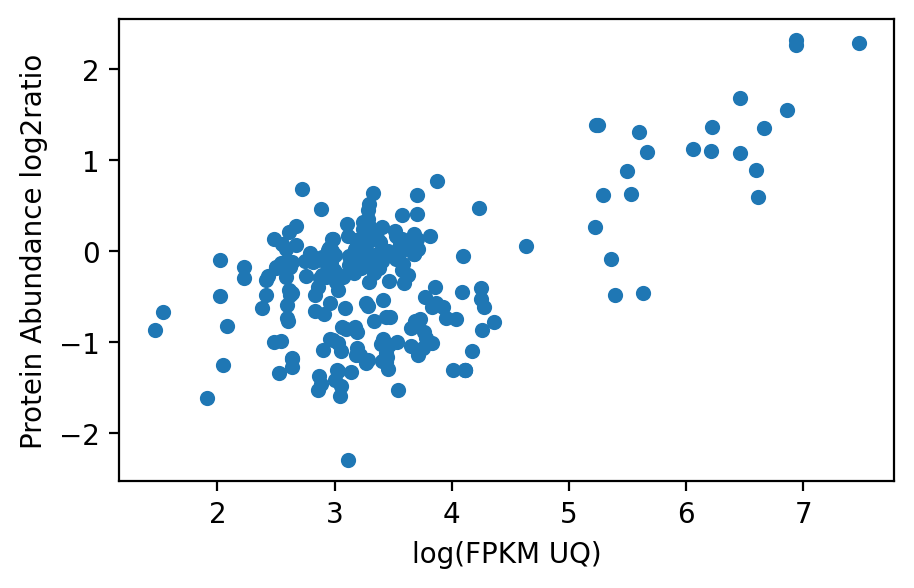

In [21]:
import matplotlib
import numpy as np

combined_df['log_fpkm_uq'] = np.log(combined_df['fpkm_uq_unstranded'])

fig, ax = plt.subplots(figsize=(5, 3))
combined_df.plot(kind="scatter", x='log_fpkm_uq', y='protein_abundance_log2ratio', ax=ax)
ax.set_ylabel("Protein Abundance log2ratio")
ax.set_xlabel("log(FPKM UQ)")
fig.show()

And finally we can generate a boxplot of RNA expression value split by mutation type present in the gene.

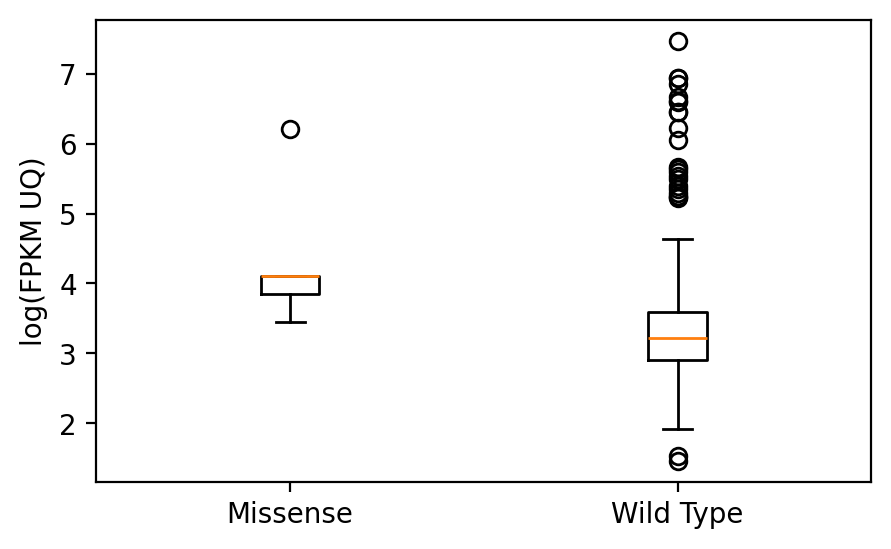

In [22]:
mutated = combined_df[combined_df['Variant_Classification'] == 'Missense_Mutation']['log_fpkm_uq']
wildtype = combined_df[combined_df['Variant_Classification'] != 'Missense_Mutation']['log_fpkm_uq']
fig, ax1 = plt.subplots(figsize=(5, 3))
bp = ax1.boxplot(x=[mutated, wildtype], tick_labels=['Missense', 'Wild Type'], )
ax1.set(ylabel="log(FPKM UQ)")
fig.show()